In [218]:
"""
The below is now replaced by the snakemake under Figure1
splitcode, version 0.30.0

config for splitcode 
@extract <13Grr_umi[10]>8{linker2},<13Grr_bc[8]>{linker2},{linker2}<13Grr_bc[8]>{linker1},{linker1}<13Grr_bc[8]>,{linker1}8<13Grr_read>0:-1
@extract <~13Gr_umi[10]>8{linker2rc},<~13Gr_bc[8]>{linker2rc},{linker2rc}<~13Gr_bc[8]>{linker1rc},{linker1rc}<~13Gr_bc[8]>,{linker1rc}8<~13Gr_read>0:-1
@extract <13Gf_bc[8]>{linker1},{linker1}<13Gf_bc[8]>{linker2},{linker2}<13Gf_bc[8]>,{linker2}8<13Gf_umi[10]>,0:0<13Gf_read>14{linker1}
@extract <~13Gfrc_bc[8]>{linker1rc},{linker1rc}<~13Gfrc_bc[8]>{linker2rc},{linker2rc}<~13Gfrc_bc[8]>,{linker2rc}8<~13Gfrc_umi[10]>,0:0<~13Gfrc_read>14{linker1rc}
groups	ids	tags	distances	locations
group1	linker1rc	   vv  	3:3:3	0:0:0
group1	linker1	ATCCACGTGCTTGAGACTGTGG	3:3:3	0:0:
group2	linker2rc	AGTCGTACGCCGATGCGAAACATCGGCCAC	3:3:3	0:0:0
group2	linker2	GTGGCCGATGTTTCGCATCGGCGTACGACT	3:3:3	0:0:0

splitcode/build/src/splitcode -c config.txt igvfb01_13G-gc_lig-ss_11.fastq.gz -o igvfb01_13G_scmodified/igvfb01_13G_lig-ss.fastq.gz

python3 run_rev.py 

ref='ref/mm39'
tech='2,0,24:1,0,10:0,0,0'
#kb ref --kallisto ${path_to_lr_kallisto} -i ${ref}_k-63.idx -k 63 -f1 ${ref}.cdna.fa -g ${ref}.t2g ${ref}.fa.gz ${ref}.gtf.gz 
sample='13G_'
output='b01_nanopore_'${sample}'_sc_single_cell'

kallisto bus -x ${tech} --long -i ${ref}_k-63.idx -o ${output} -t 32 ${sample}read.fastq.gz ${sample}umi.fastq.gz ${sample}bc.fastq.gz

${path_to_bustools} sort -t 32 ${output}/output.bus \
 -o ${output}/sorted.bus; \
 ${path_to_bustools} whitelist --threshold 200 -o ${output}/whitelist.txt \
 ${output}/sorted.bus; \
 ${path_to_bustools} correct -w ${output}/whitelist.txt \
 -o ${output}/corrected.bus ${output}/sorted.bus; \ 
 ${path_to_bustools} capture -b -c ${output}/whitelist.txt \
 -o ${output}/captured.bus ${output}/corrected.bus; \
 ${path_to_bustools} count ${output}/captured.bus \
 -t ${output}/transcripts.txt \
 -e ${output}/matrix.ec \
 -o ${output}/count -m \
 -g ${ref}.t2g; \
 ${path_to_lr_kallisto} quant-tcc -t 32 \
 ${output}/count.mtx \
 -i ${ref}_k-63.idx \
 -f ${output}/flens.txt \
 -e ${output}/count.ec.txt \
 -o ${output};

 ${path_to_bustools} count ${output}/corrected.bus \
 -t ${output}/transcripts.txt \
 -e ${output}/matrix.ec \
 -o ${output}/gcount --em --genecounts \
 -g ${ref}.t2g;
"""

"\nsplitcode, version 0.30.0\n\nconfig for splitcode \n@extract <13Grr_umi[10]>8{linker2},<13Grr_bc[8]>{linker2},{linker2}<13Grr_bc[8]>{linker1},{linker1}<13Grr_bc[8]>,{linker1}8<13Grr_read>0:-1\n@extract <~13Gr_umi[10]>8{linker2rc},<~13Gr_bc[8]>{linker2rc},{linker2rc}<~13Gr_bc[8]>{linker1rc},{linker1rc}<~13Gr_bc[8]>,{linker1rc}8<~13Gr_read>0:-1\n@extract <13Gf_bc[8]>{linker1},{linker1}<13Gf_bc[8]>{linker2},{linker2}<13Gf_bc[8]>,{linker2}8<13Gf_umi[10]>,0:0<13Gf_read>14{linker1}\n@extract <~13Gfrc_bc[8]>{linker1rc},{linker1rc}<~13Gfrc_bc[8]>{linker2rc},{linker2rc}<~13Gfrc_bc[8]>,{linker2rc}8<~13Gfrc_umi[10]>,0:0<~13Gfrc_read>14{linker1rc}\ngroups\tids\ttags\tdistances\tlocations\ngroup1\tlinker1rc\t   vv  \t3:3:3\t0:0:0\ngroup1\tlinker1\tATCCACGTGCTTGAGACTGTGG\t3:3:3\t0:0:\ngroup2\tlinker2rc\tAGTCGTACGCCGATGCGAAACATCGGCCAC\t3:3:3\t0:0:0\ngroup2\tlinker2\tGTGGCCGATGTTTCGCATCGGCGTACGACT\t3:3:3\t0:0:0\n\nsplitcode/build/src/splitcode -c config.txt igvfb01_13G-gc_lig-ss_11.fastq.gz -o igvf

In [219]:
# Import packages
import scipy
import anndata
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io
import seaborn as sns

matplotlib.rcParams.update({'font.size': 12})
%config InlineBackend.figure_format = 'retina'
# import data
#dir = '13G_single_cell/b01_nanopore_13G_single_cell/counts_unfiltered' #b01_nanopore_13G_single_cell' #'b01_nanopore_tsosc_rt_single_cell'#'b01_nanopore_13G_sc_rt_single_cell' #'b01_nanopore_13G_single_cell'#'b01_nanopore_13G__sc_single_cell'
dir = '1213_b01_diane/b01_nanopore_13G_single_cell_k63_both_mm39/counts_unfiltered/cells_x_genes'
adata = sc.read_mtx(dir+".mtx")
adata.obs.index = pd.read_csv(dir+".barcodes.txt", header=None)[0].values
adata.var.index = pd.read_csv(dir+".genes.txt", header=None)[0].values


In [220]:
#dir_Illumina = '13G_single_cell/b01_next1_13G_single_cell/counts_unfiltered'
dir_Illumina = '1213_b01_diane/b01_next1_13G_single_cell_k31_both_mm39/counts_unfiltered/cells_x_genes'
Iadata = sc.read_mtx(dir_Illumina+".mtx")
Iadata.obs.index = pd.read_csv(dir_Illumina+".barcodes.txt", header=None)[0].values
Iadata.var.index = pd.read_csv(dir_Illumina+".genes.txt", header=None)[0].values

In [221]:
adata.var

""
ENSMUSG00000102693.2
ENSMUSG00000064842.3
ENSMUSG00000051951.6
ENSMUSG00000102851.2
ENSMUSG00000103377.2
...
ENSMUSG00000095366.3
ENSMUSG00000095134.3
ENSMUSG00000096768.9
ENSMUSG00000099871.2


In [222]:
Iadata.var

""
ENSMUSG00000102693.2
ENSMUSG00000064842.3
ENSMUSG00000051951.6
ENSMUSG00000102851.2
ENSMUSG00000103377.2
...
ENSMUSG00000095366.3
ENSMUSG00000095134.3
ENSMUSG00000096768.9
ENSMUSG00000099871.2


In [223]:
Iadata.obs

""
AAACATCGAACAACCAATTTGGCA
AAACATCGAACAACCATATGTGTC
AAACATCGAACTCACCCCATCTTG
AAACATCGAACTCACCTAGTTTCC
AAACATCGAACTCACCTCATTGCA
...
TTCACGCATCTTCACATTATTCTG
TTCACGCATGAAGAGAATCCTTAC
TTCACGCATGAAGAGATACTGTCT
TTCACGCATGGTGGTAACATTTAC


In [224]:
adata.obs

""
AAACATCGAACAACCAATTTGGCA
AAACATCGAACTCACCTCATTGCA
AAACATCGAACTCACCTCTCATGC
AAACATCGAAGAGATCTCATTGCA
AAACATCGAAGGTACACATGTCTC
...
TTCACGCATCTTCACAGCTATCAT
TTCACGCATCTTCACATTATTCTG
TTCACGCATGAAGAGAATCCTTAC
TTCACGCATGGTGGTAACATTTAC


In [225]:
Iadata.obs.index

Index(['AAACATCGAACAACCAATTTGGCA', 'AAACATCGAACAACCATATGTGTC',
       'AAACATCGAACTCACCCCATCTTG', 'AAACATCGAACTCACCTAGTTTCC',
       'AAACATCGAACTCACCTCATTGCA', 'AAACATCGAACTCACCTCTCATGC',
       'AAACATCGAAGAGATCTAGTTTCC', 'AAACATCGAAGAGATCTCATTGCA',
       'AAACATCGAAGGTACACATGTCTC', 'AAACATCGAAGGTACAGCTATCTC',
       ...
       'TTCACGCATCCGTCTATAAATATC', 'TTCACGCATCCGTCTATTCATCGC',
       'TTCACGCATCTTCACACAATTCTC', 'TTCACGCATCTTCACAGCTATCAT',
       'TTCACGCATCTTCACAGTGCTTGA', 'TTCACGCATCTTCACATTATTCTG',
       'TTCACGCATGAAGAGAATCCTTAC', 'TTCACGCATGAAGAGATACTGTCT',
       'TTCACGCATGGTGGTAACATTTAC', 'TTCACGCATGGTGGTAGCTTCATA'],
      dtype='object', length=21390)

In [226]:
adata.obs.index

Index(['AAACATCGAACAACCAATTTGGCA', 'AAACATCGAACTCACCTCATTGCA',
       'AAACATCGAACTCACCTCTCATGC', 'AAACATCGAAGAGATCTCATTGCA',
       'AAACATCGAAGGTACACATGTCTC', 'AAACATCGAATCCGTCACTGCTCT',
       'AAACATCGAATCCGTCCTTCTAAC', 'AAACATCGAATCCGTCTCTCATGC',
       'AAACATCGAATGTTGCCCAATTCT', 'AAACATCGACAAGCTAGCTATCAT',
       ...
       'TTCACGCAGTCTGTCATTATTCTG', 'TTCACGCATAGGATGAATCCTTAC',
       'TTCACGCATATCAGCACATACTTC', 'TTCACGCATCCGTCTACCGTTCTA',
       'TTCACGCATCCGTCTATAAATATC', 'TTCACGCATCTTCACAGCTATCAT',
       'TTCACGCATCTTCACATTATTCTG', 'TTCACGCATGAAGAGAATCCTTAC',
       'TTCACGCATGGTGGTAACATTTAC', 'TTCACGCATGGTGGTAGCTTCATA'],
      dtype='object', length=10532)

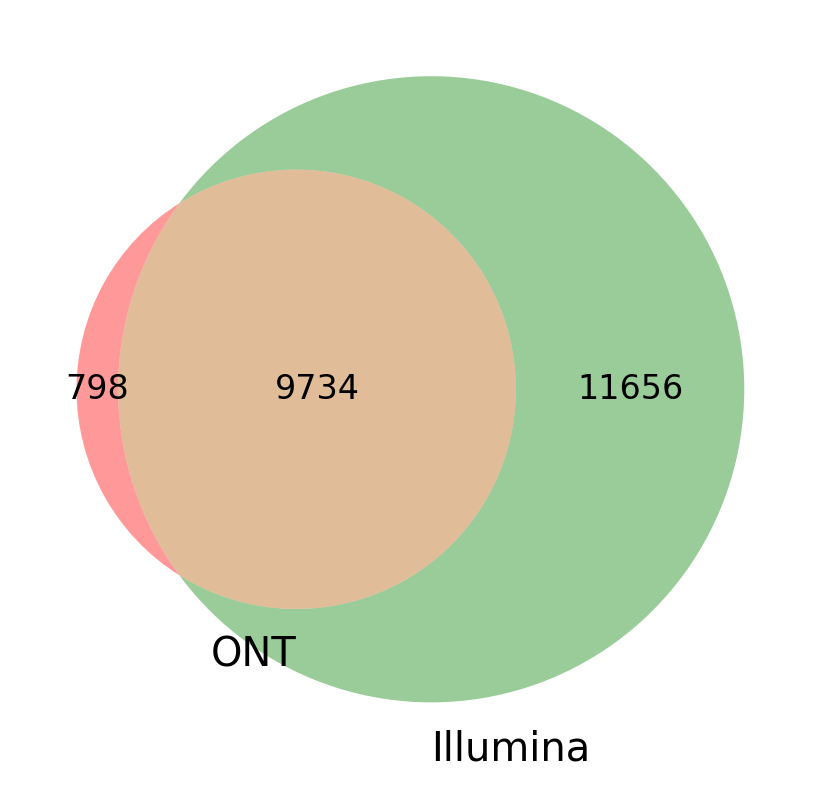

In [227]:
#!pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

aadata = [t for t in adata.obs.index]
iadata = [t for t in Iadata.obs.index]

venn2((set(aadata), set(iadata)), ('ONT', 'Illumina'))

In [228]:
#adata.obs_names_make_unique()
#sc.pp.filter_genes(adata, min_cells=100, inplace=True)
sc.pp.calculate_qc_metrics(adata, inplace=True)
#sc.pp.filter_cells(adata, min_genes=200, inplace=True)#min_genes=300) 
sc.pp.filter_genes(adata, min_cells=100, inplace=True)
sc.pp.filter_cells(adata, min_counts=500, inplace=True)#min_genes=300) 
#adata = adata[:, adata.var["n_counts"]]
#adata = adata[:, adata.var["n_cells"]]
#Iadata.obs_names_make_unique()
sc.pp.calculate_qc_metrics(Iadata, inplace=True)
#sc.pp.filter_cells(Iadata, min_genes=200, inplace=True)#min_genes=300) 
sc.pp.filter_genes(Iadata, min_cells=100, inplace=True)
sc.pp.filter_cells(Iadata, min_counts=500, inplace=True)#min_genes=300) 
#Iadata = Iadata[:, Iadata.var["n_counts"]]
#sc.pp.filter_genes(Iadata, min_cells=100, inplace=True)
#Iadata = Iadata[:, Iadata.var["n_cells"]]

In [229]:
adata

AnnData object with n_obs × n_vars = 8844 × 10475
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [230]:
Iadata

AnnData object with n_obs × n_vars = 19564 × 15473
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

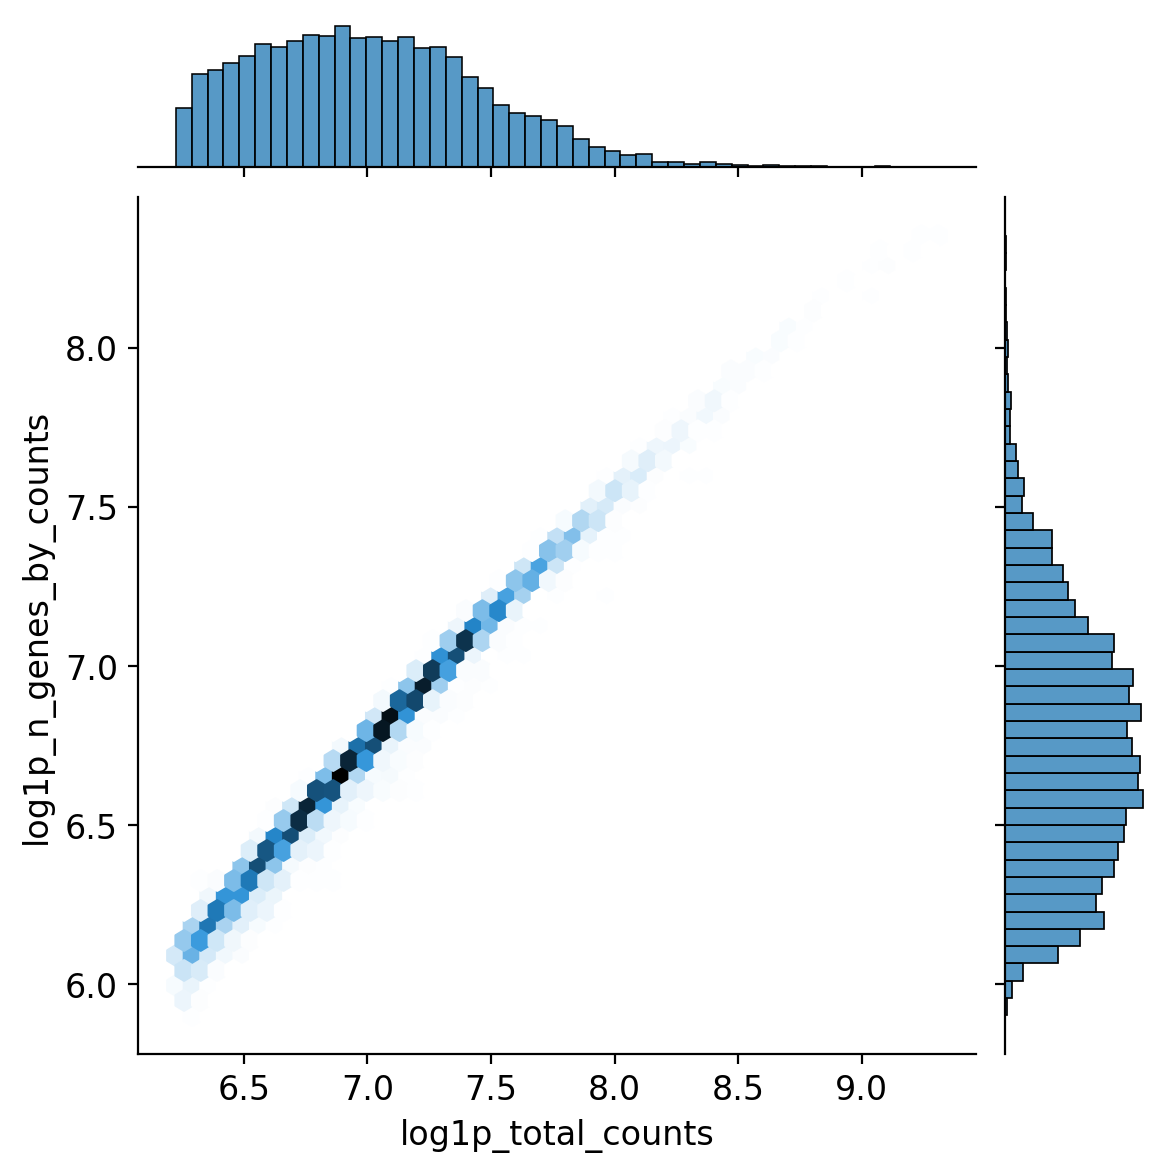

In [231]:
sns.jointplot(
    data=adata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

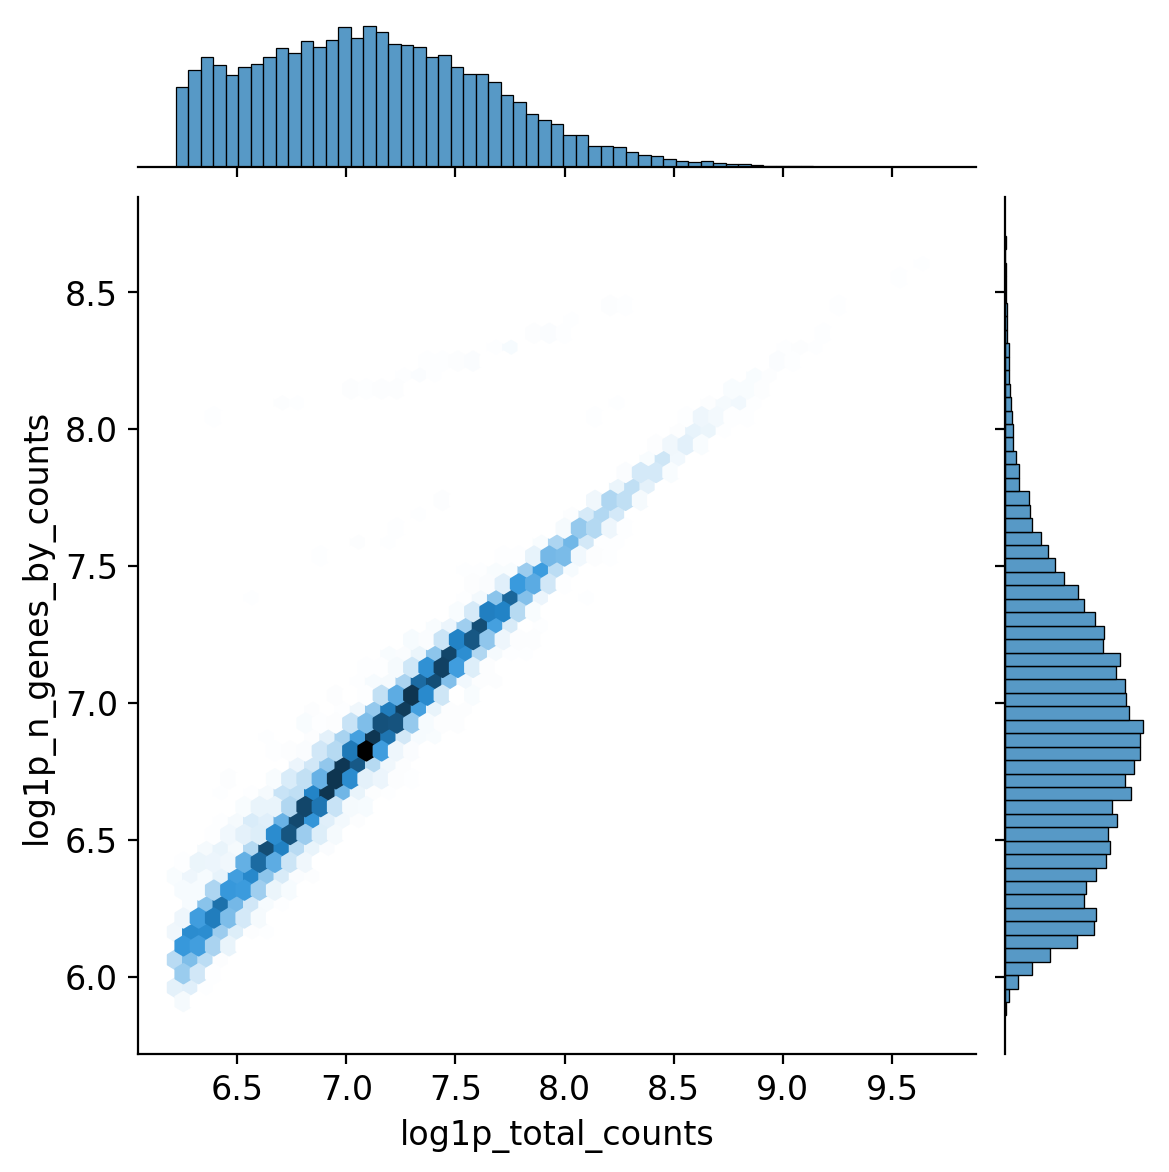

In [232]:
sns.jointplot(
    data=Iadata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

In [233]:
#adata.obs_names_make_unique()
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)

#Iadata.obs_names_make_unique()
sc.pp.normalize_per_cell(Iadata, counts_per_cell_after=1e4)
sc.pp.log1p(Iadata)

In [234]:
def rev_comp(dna):
    """
    This function takes a DNA sequence as input and returns its reverse complement.
    """

    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join([complement[base] for base in dna[::-1]])

dna_seq = "ATCGTACG"
print(rev_comp(dna_seq))
intersect = [t for t in adata.obs.index]
intersecta = [t for t in adata.obs.index if t in Iadata.obs.index.values]
intersectsc = [t for t in adata.obs.index if t in Iadata.obs.index]

#if 'TCATGCTC_AACGCTTA_AACGTGAT'
if 'AACGTGATAACGCTTATCATGCTC' in Iadata.obs.index.values:
    print("hello, moon")
if 'AACGTGATAACGCTTATCATGCTC' in adata.obs.index.values:
    print("hello, moon")

CGTACGAT
hello, moon
hello, moon


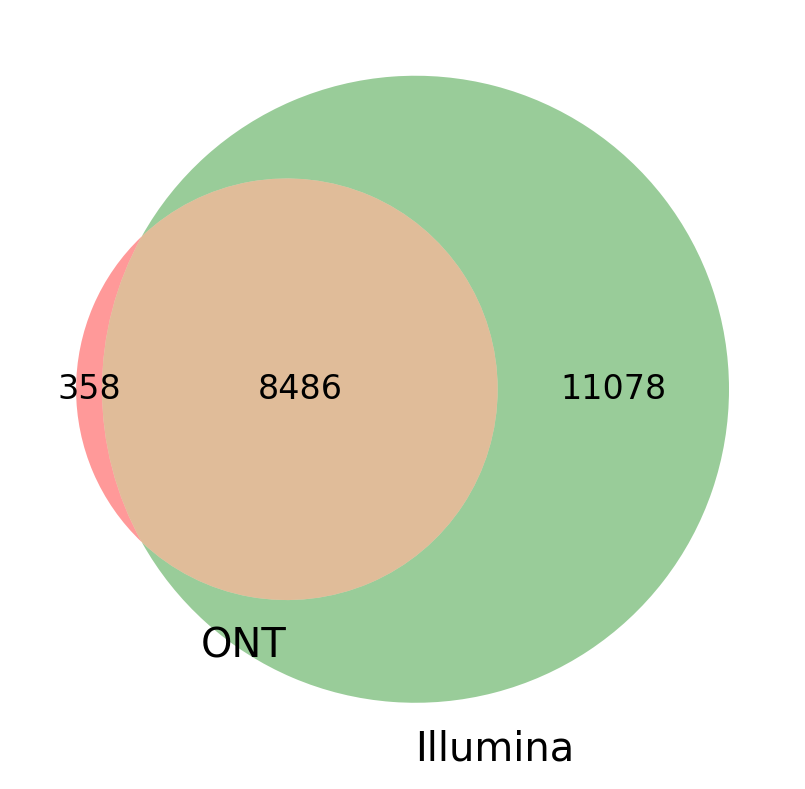

In [235]:
#!pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
intersect = [t for t in adata.obs.index]

iadata = [t for t in Iadata.obs.index]

venn2((set(intersect), set(iadata)), ('ONT', 'Illumina'))


In [236]:
'''
dir_Illumina = '13G_single_cell/b01_next1_13G_single_cell'
Iadata = sc.read_mtx(dir_Illumina+"/gcount.mtx")
Iadata.obs.index = pd.read_csv(dir_Illumina+"/gcount.barcodes.txt", header=None)[0].values
Iadata.var.index = pd.read_csv(dir_Illumina+"/gcount.genes.txt", header=None)[0].values
'''

'\ndir_Illumina = \'13G_single_cell/b01_next1_13G_single_cell\'\nIadata = sc.read_mtx(dir_Illumina+"/gcount.mtx")\nIadata.obs.index = pd.read_csv(dir_Illumina+"/gcount.barcodes.txt", header=None)[0].values\nIadata.var.index = pd.read_csv(dir_Illumina+"/gcount.genes.txt", header=None)[0].values\n'

In [237]:
#venn2((set(intersect), set(iadata+[t for t in Iadata.obs.index])), ('ONT', 'Illumina'))

In [238]:
intersect_g = [gene for gene in adata.var.index if gene in Iadata.var.index]

In [239]:
print(len(intersecta))
print(len(intersect))
print(len(intersectsc))
print(len(intersect_g))

8486
8844
8486
10446


In [240]:
Iadata.var.index

Index(['ENSMUSG00000051951.6', 'ENSMUSG00000104017.2', 'ENSMUSG00000103147.2',
       'ENSMUSG00000103161.2', 'ENSMUSG00000102331.2', 'ENSMUSG00000103922.2',
       'ENSMUSG00000033845.14', 'ENSMUSG00000102275.2',
       'ENSMUSG00000025903.15', 'ENSMUSG00000104217.2',
       ...
       'ENSMUSG00000121544.1', 'ENSMUSG00000121546.1', 'ENSMUSG00000121552.1',
       'ENSMUSG00000121553.1', 'ENSMUSG00000121554.1', 'ENSMUSG00000099840.3',
       'ENSMUSG00000095366.3', 'ENSMUSG00000095134.3', 'ENSMUSG00000096768.9',
       'ENSMUSG00000099871.2'],
      dtype='object', length=15473)

In [241]:
#Iadata.obs_names_make_unique(join='-')
    
adata[intersectsc, intersect_g]
pearson_gene_ONT_vs_Ill = []
for c in intersecta:
    if np.squeeze(np.asarray(adata[c, intersect_g].X.todense())).all() != 1:
        pearson=scipy.stats.pearsonr(np.squeeze(np.asarray(adata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Iadata[c, intersect_g].X.todense())))
        pearson_gene_ONT_vs_Ill.append(pearson[0])

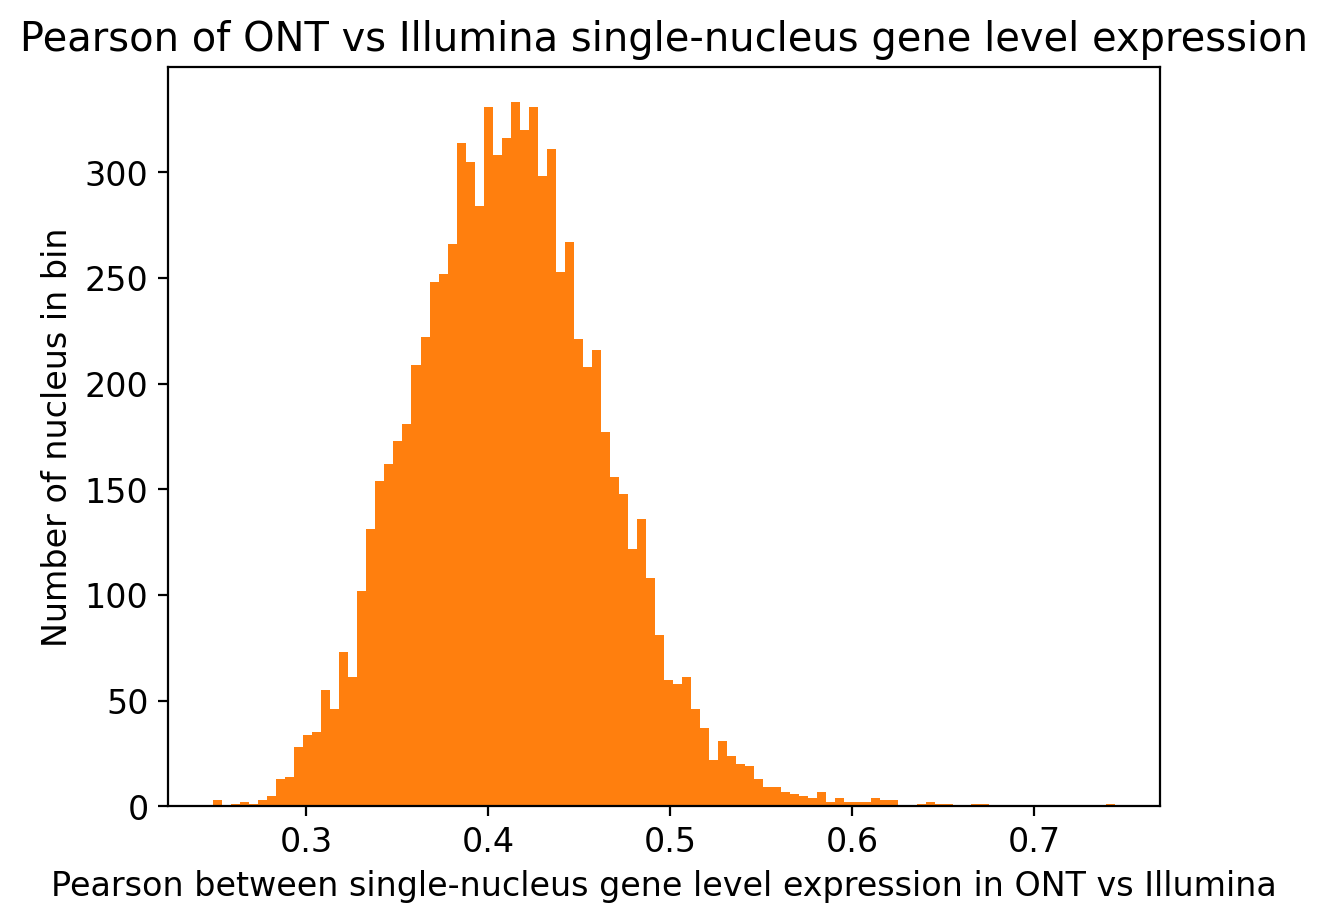

8486

In [242]:
import matplotlib.pyplot as plt

plt.hist(pearson_gene_ONT_vs_Ill, bins=100, color='C1')
plt.xlabel("Pearson between single-nucleus gene level expression in ONT vs Illumina")
plt.ylabel("Number of nucleus in bin")
plt.title("Pearson of ONT vs Illumina single-nucleus gene level expression")
plt.show()
len(pearson_gene_ONT_vs_Ill)

In [243]:
#Iadata.obs_names_make_unique(join='-')
    
adata[intersectsc, intersect_g]
spearman_gene_ONT_vs_Ill = []
for c in intersecta:
    if np.squeeze(np.asarray(adata[c, intersect_g].X.todense())).all() != 1:
        spearman=scipy.stats.spearmanr(np.squeeze(np.asarray(adata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Iadata[c, intersect_g].X.todense())))
        spearman_gene_ONT_vs_Ill.append(spearman[0])

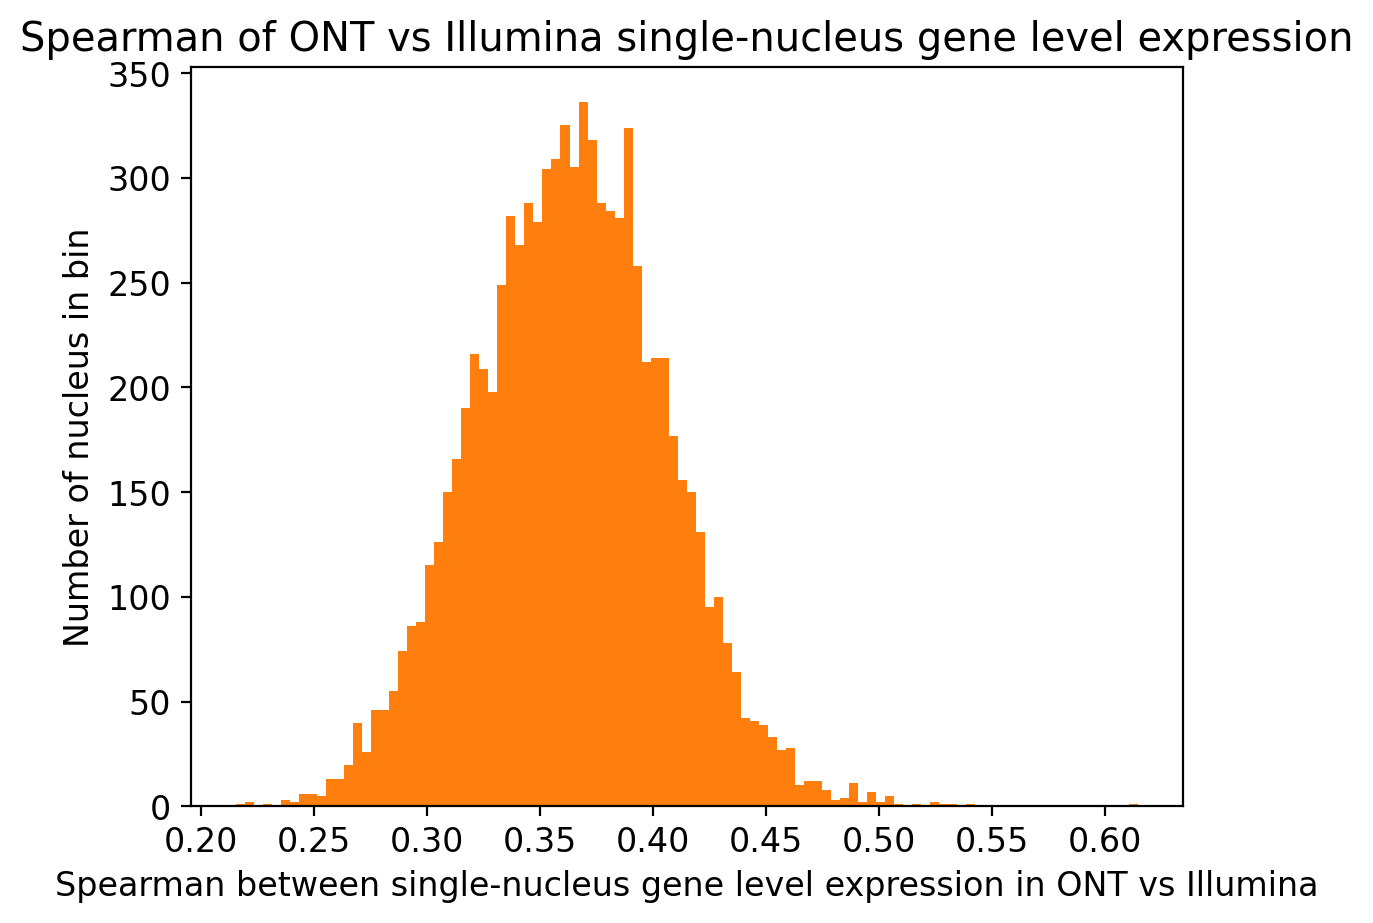

8486

In [244]:
import matplotlib.pyplot as plt

plt.hist(spearman_gene_ONT_vs_Ill, bins=100, color='C1')
plt.xlabel("Spearman between single-nucleus gene level expression in ONT vs Illumina")
plt.ylabel("Number of nucleus in bin")
plt.title("Spearman of ONT vs Illumina single-nucleus gene level expression")
plt.show()
len(spearman_gene_ONT_vs_Ill)

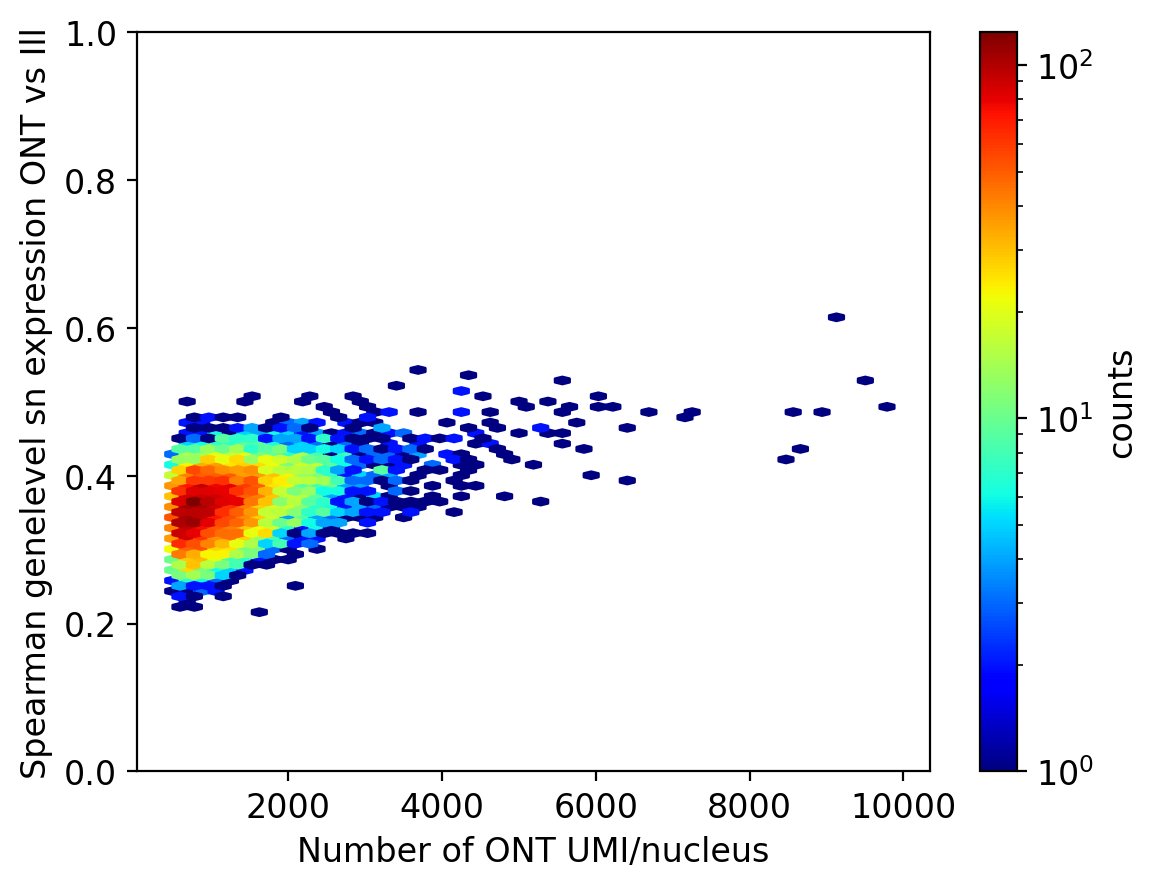

In [245]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(adata[intersectsc, intersect_g].obs['n_counts'], spearman_gene_ONT_vs_Ill, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel sn expression ONT vs Ill")
plt.xlabel("Number of ONT UMI/nucleus")
plt.ylim((0,1))
plt.colorbar(label='counts')
plt.show()

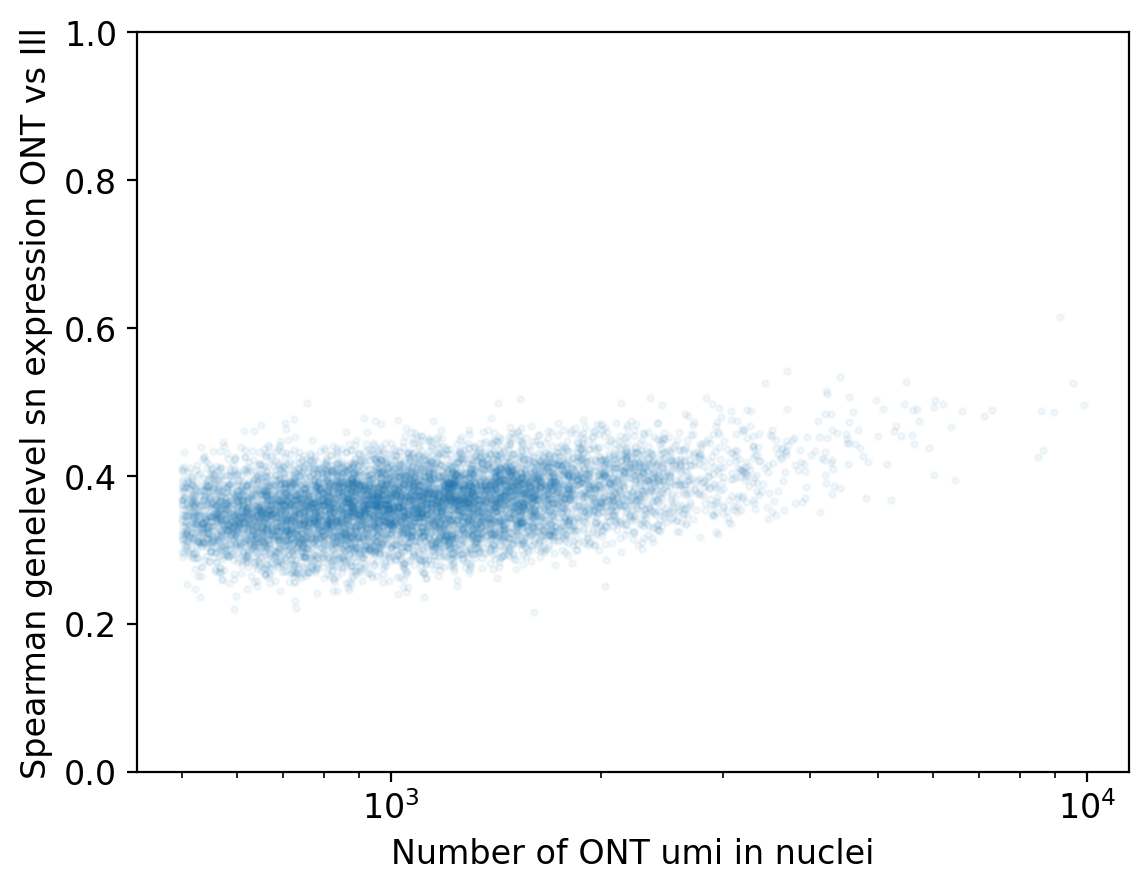

In [246]:
plt.scatter(adata[intersectsc, intersect_g].obs['n_counts'], spearman_gene_ONT_vs_Ill, alpha=0.05, s=5)
plt.xscale('log')
#plt.hexbin(Iadata.obs['n_counts'][intersect], spearman_gene_ONT_vs_Ill, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel sn expression ONT vs Ill")
plt.xlabel("Number of ONT umi in nuclei")
plt.ylim((0,1))
#plt.colorbar(label='counts')
plt.show()